# **Credit Card Approval ML Project**


# ========================================================
#  IMPORTS
# ========================================================

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'svg'
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import optuna
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve,make_scorer

# Dataset Preprocessing

### Application Record Dataset Features

In [3]:
application= pd.read_csv("application_record.csv")
application.head(5)

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


In [4]:
application.shape

(438557, 18)

In [5]:
application.rename(columns={'CODE_GENDER':'Gender','FLAG_OWN_CAR':'Car','FLAG_OWN_REALTY':'Realty',
                         'CNT_CHILDREN':'Childnmbr','AMT_INCOME_TOTAL':'TotalIncome',
                         'NAME_INCOME_TYPE':'Incometype','NAME_EDUCATION_TYPE':'Edu','NAME_FAMILY_STATUS':'Fam',
                        'NAME_HOUSING_TYPE':'Housing','DAYS_BIRTH':'Birthday', 'DAYS_EMPLOYED':'EmplymntDate',
                        'FLAG_EMAIL':'email','NAME_INCOME_TYPE':'Incometype','FLAG_WORK_PHONE':'workphn',
                         'FLAG_MOBIL':'mobil','FLAG_PHONE':'phone','CNT_FAM_MEMBERS':'famsize',
                        'OCCUPATION_TYPE':'Occupation'
                        },inplace=True)

In [6]:
application.head(3)

,ID,Gender,Car,Realty,Childnmbr,TotalIncome,Incometype,Edu,Fam,Housing,Birthday,EmplymntDate,mobil,workphn,phone,email,Occupation,famsize
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0


In [7]:
application.isnull().sum()

ID                   0
Gender               0
Car                  0
Realty               0
Childnmbr            0
TotalIncome          0
Incometype           0
Edu                  0
Fam                  0
Housing              0
Birthday             0
EmplymntDate         0
mobil                0
workphn              0
phone                0
email                0
Occupation      134203
famsize              0
dtype: int64

In [8]:
application=application.dropna()

In [9]:
application.info()

<class 'pandas.core.frame.DataFrame'>
Index: 304354 entries, 2 to 438556
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   ID            304354 non-null  int64  
 1   Gender        304354 non-null  object 
 2   Car           304354 non-null  object 
 3   Realty        304354 non-null  object 
 4   Childnmbr     304354 non-null  int64  
 5   TotalIncome   304354 non-null  float64
 6   Incometype    304354 non-null  object 
 7   Edu           304354 non-null  object 
 8   Fam           304354 non-null  object 
 9   Housing       304354 non-null  object 
 10  Birthday      304354 non-null  int64  
 11  EmplymntDate  304354 non-null  int64  
 12  mobil         304354 non-null  int64  
 13  workphn       304354 non-null  int64  
 14  phone         304354 non-null  int64  
 15  email         304354 non-null  int64  
 16  Occupation    304354 non-null  object 
 17  famsize       304354 non-null  float64
dtypes: float6

In [10]:
application.duplicated(subset=['ID']).sum()

23

In [11]:
application.drop_duplicates(subset=['ID'], inplace=True)


In [12]:
application['Age']=(-application['Birthday']/365).astype(int)

In [13]:
application["WorkingYears"] = application["EmplymntDate"].apply(lambda x: float(-x / 365) if pd.notnull(x) and x < 0 else -1)

In [14]:
application=application.drop(['Birthday', 'EmplymntDate'], axis=1)


### Visualization of the Application dataset


In [1]:
def categorical_bar_charts(df, columns, titles=None, max_cols=2):
    n = len(columns)
    rows = (n + max_cols - 1) // max_cols

    plt.figure(figsize=(5 * max_cols, 4 * rows))

    for i, col in enumerate(columns):
        plt.subplot(rows, max_cols, i + 1)
        sns.countplot(data=df, x=col, palette='pastel', order=df[col].value_counts().index)
        plt.title(titles[i] if titles else col)
        plt.xticks(rotation=45)
        plt.xlabel("")
        plt.ylabel("Count")

    plt.tight_layout()
    plt.suptitle("Distributions of Applicants", fontsize=16, y=1.02)
    plt.show()



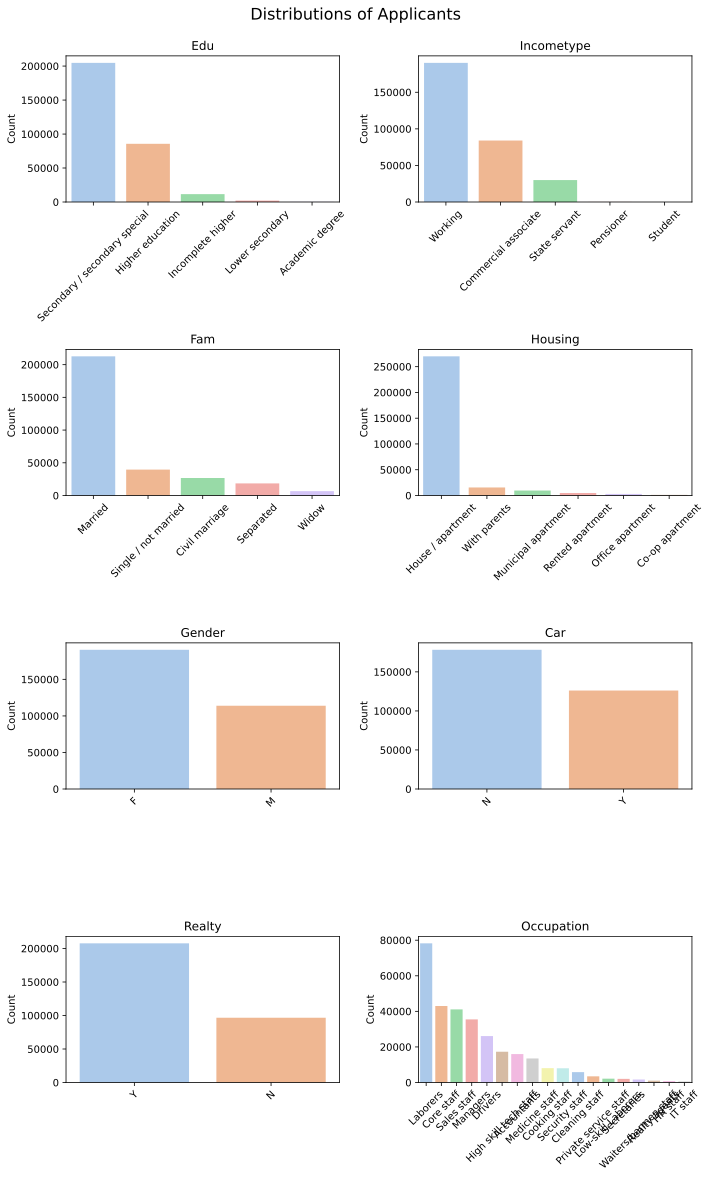

In [16]:
columns=['Edu', 'Incometype', 'Fam', 'Housing', 'Gender', 'Car', 'Realty', 'Occupation']
categorical_bar_charts(application, columns)

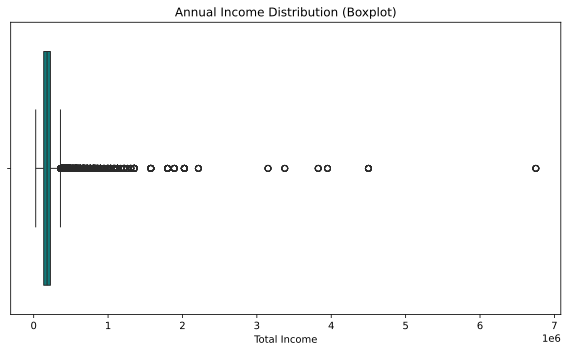

In [17]:

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=application,
    x='TotalIncome',
    color='darkcyan'
)

plt.title('Annual Income Distribution (Boxplot)')
plt.xlabel('Total Income')
plt.tight_layout()
plt.show()

### Credit Record Dataset

In [18]:
credit=pd.read_csv("credit_record.csv")
credit.head(5)

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


In [19]:
credit['STATUS'].value_counts()

STATUS
C    442031
0    383120
X    209230
1     11090
5      1693
2       868
3       320
4       223
Name: count, dtype: int64

In [20]:
credit["STATUS"]=credit["STATUS"].astype(str)
credit['STATUS']=credit['STATUS'].apply(lambda x: "Good_Debt" if x in ["X", "C"] else "Bad_Debt")


In [21]:
credit['STATUS'].value_counts(normalize=True)

STATUS
Good_Debt    0.621091
Bad_Debt     0.378909
Name: proportion, dtype: float64

In [22]:
status_counts = credit.groupby("ID")['STATUS'].value_counts().unstack(fill_value=0)


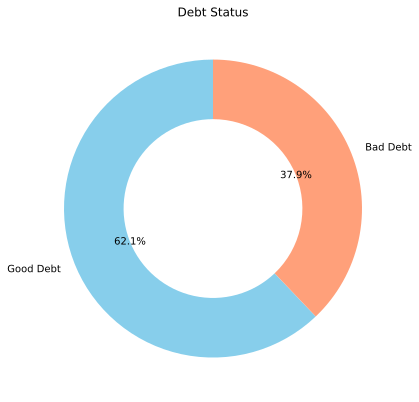

In [23]:
labels = ['Good Debt', 'Bad Debt']
sizes = [status_counts['Good_Debt'].sum(), status_counts['Bad_Debt'].sum()]
colors = ['#87CEEB', '#FFA07A'] 

plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, colors=colors, startangle=90, 
        wedgeprops={'width': 0.4}, autopct='%1.1f%%')
plt.title('Debt Status')
plt.tight_layout()
plt.show()


In [24]:
df_app=application.set_index("ID").join(status_counts)

In [25]:
df_app.info()
print(df_app.shape)

<class 'pandas.core.frame.DataFrame'>
Index: 304331 entries, 5008806 to 6842885
Data columns (total 19 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Gender        304331 non-null  object 
 1   Car           304331 non-null  object 
 2   Realty        304331 non-null  object 
 3   Childnmbr     304331 non-null  int64  
 4   TotalIncome   304331 non-null  float64
 5   Incometype    304331 non-null  object 
 6   Edu           304331 non-null  object 
 7   Fam           304331 non-null  object 
 8   Housing       304331 non-null  object 
 9   mobil         304331 non-null  int64  
 10  workphn       304331 non-null  int64  
 11  phone         304331 non-null  int64  
 12  email         304331 non-null  int64  
 13  Occupation    304331 non-null  object 
 14  famsize       304331 non-null  float64
 15  Age           304331 non-null  int32  
 16  WorkingYears  304331 non-null  float64
 17  Bad_Debt      25134 non-null   float64
 18  Go

# 2.Dealing with Imbalanced Data

In [26]:
df_app[['Good_Debt', 'Bad_Debt']] = df_app[['Good_Debt', 'Bad_Debt']].fillna(0)
((df_app['Good_Debt'] == 0) & (df_app['Bad_Debt'] == 0)).sum()

279197

In [27]:
income_threshold = 75000 

df_app['applicant_status'] = np.where(
    (df_app['Good_Debt'] == 0) & (df_app['Bad_Debt'] == 0),
        np.where(df_app['TotalIncome'] > income_threshold, 'good', 'bad'),
    np.where(
        df_app['Good_Debt'] > df_app['Bad_Debt'],  
        'good',
        'bad'
    )
)

print(df_app['applicant_status'].value_counts())

applicant_status
good    283993
bad      20338
Name: count, dtype: int64


## Encoding Categorical Features


In [28]:
df_encoded=df_app.copy()


In [29]:

categorical_cols = ['Gender', 'Car', 'Realty', 'Incometype', 'Edu', 'Fam', 'Housing', 'Occupation','applicant_status']

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    label_encoders[col] = le 

In [30]:
df_encoded['applicant_status'].value_counts()

applicant_status
1    283993
0     20338
Name: count, dtype: int64

In [31]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 304331 entries, 5008806 to 6842885
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Gender            304331 non-null  int32  
 1   Car               304331 non-null  int32  
 2   Realty            304331 non-null  int32  
 3   Childnmbr         304331 non-null  int64  
 4   TotalIncome       304331 non-null  float64
 5   Incometype        304331 non-null  int32  
 6   Edu               304331 non-null  int32  
 7   Fam               304331 non-null  int32  
 8   Housing           304331 non-null  int32  
 9   mobil             304331 non-null  int64  
 10  workphn           304331 non-null  int64  
 11  phone             304331 non-null  int64  
 12  email             304331 non-null  int64  
 13  Occupation        304331 non-null  int32  
 14  famsize           304331 non-null  float64
 15  Age               304331 non-null  int32  
 16  WorkingYears      

In [32]:
df_encoded.corr()

,Gender,Car,Realty,Childnmbr,TotalIncome,Incometype,Edu,Fam,Housing,mobil,workphn,phone,email,Occupation,famsize,Age,WorkingYears,Bad_Debt,Good_Debt,applicant_status
Gender,1.000000,0.331666,-0.034239,0.040314,0.153764,0.015468,0.040543,-0.042518,0.046243,NaN,-0.016474,-0.027940,-0.003179,-0.028309,0.063062,-0.106156,-0.106556,0.001551,0.002263,0.059572
Car,0.331666,1.000000,0.012058,0.076338,0.173572,-0.018457,-0.073924,-0.089990,-0.011374,NaN,-0.035635,-0.010330,0.023780,-0.038876,0.114243,-0.067988,-0.042734,0.006088,0.007035,0.046511
Realty,-0.034239,0.012058,1.000000,0.014345,0.029055,-0.022703,0.009150,-0.008503,-0.179857,NaN,-0.180182,-0.077381,0.071083,0.005186,0.019271,0.091761,0.024376,-0.016895,-0.017753,0.016679
Childnmbr,0.040314,0.076338,0.014345,1.000000,-0.021250,0.027592,-0.008468,-0.146252,0.005709,NaN,-0.021572,-0.044691,0.006431,-0.011461,0.899205,-0.261153,-0.072993,-0.000120,-0.001759,-0.013232
TotalIncome,0.153764,0.173572,0.029055,-0.021250,1.000000,-0.154294,-0.207163,0.010583,-0.025421,NaN,-0.069974,0.005998,0.094298,-0.012079,-0.025198,0.063212,0.021938,0.008373,0.001214,0.121331
Incometype,0.015468,-0.018457,-0.022703,0.027592,-0.154294,1.000000,0.128649,-0.000597,-0.001941,NaN,0.072568,0.009653,-0.059678,0.003763,0.025184,-0.008295,0.029564,-0.006003,-0.000535,-0.033239
Edu,0.040543,-0.073924,0.009150,-0.008468,-0.207163,0.128649,1.000000,-0.026791,-0.008093,NaN,0.009291,-0.038072,-0.105867,0.133541,0.005000,0.113432,0.033767,0.001097,-0.004487,-0.046149
Fam,-0.042518,-0.089990,-0.008503,-0.146252,0.010583,-0.000597,-0.026791,1.000000,0.064371,NaN,-0.024406,-0.011805,0.006269,-0.001657,-0.515466,0.008263,-0.001096,0.001867,-0.004590,0.006239
Housing,0.046243,-0.011374,-0.179857,0.005709,-0.025421,-0.001941,-0.008093,0.064371,1.000000,NaN,-0.000003,-0.028457,-0.000480,-0.001991,-0.031483,-0.201515,-0.088176,0.000972,0.002168,-0.003989
mobil,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


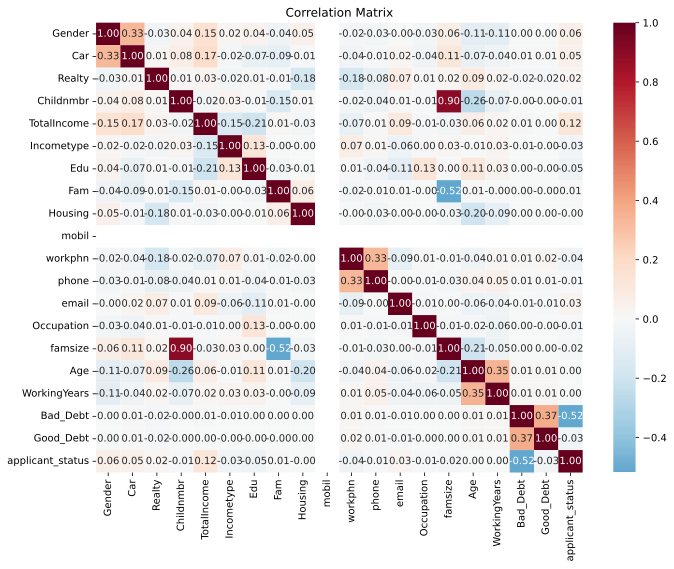

In [33]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    df_encoded.corr(),
    annot=True,        
    fmt=".2f",         
    cmap="RdBu_r",     
    center=0           
)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

## SMOTE

We applied `SMOTE` to address severe class imbalance in the dataset (e.g., far fewer *bad/no_record* cases than *good*). Imbalanced data can bias models toward the majority class, leading to poor detection of high-risk cases.

In [34]:
X = df_encoded.drop(['applicant_status', 'Good_Debt', 'Bad_Debt'], axis=1)
y = df_encoded['applicant_status']

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print(pd.Series(y_resampled).value_counts())

applicant_status
1    283993
0    283993
Name: count, dtype: int64


# ========================================================
# 8. TRAIN-TEST SPLIT
# ========================================================

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, 
    test_size=0.3, 
    random_state=42)

print("Train set:\n", y_train.value_counts())
print("\nTest set:\n", y_test.value_counts())

Train set:
 applicant_status
1    198883
0    198707
Name: count, dtype: int64

Test set:
 applicant_status
0    85286
1    85110
Name: count, dtype: int64


# 3.Modelling

### Now we will use Optuna to hyperparameter optimization of Random Forest Classification model.

In [ ]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 10, 200),
        'max_depth': trial.suggest_int('max_depth', 5, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10)
    }
    model = RandomForestClassifier(**params)
    return cross_val_score(model, X_train, y_train, cv=3, scoring='f1_weighted').mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)       

print("Best parameters:", study.best_params)
print("F1 Score:", study.best_value)

[I 2026-02-02 20:29:31,457] A new study created in memory with name: no-name-7e996e67-928a-4568-9650-d3f8d5722da6
[I 2026-02-02 20:31:13,688] Trial 0 finished with value: 0.9140183020692555 and parameters: {'n_estimators': 107, 'max_depth': 17, 'min_samples_split': 7}. Best is trial 0 with value: 0.9140183020692555.
[I 2026-02-02 20:33:56,109] Trial 1 finished with value: 0.9726778848245846 and parameters: {'n_estimators': 150, 'max_depth': 29, 'min_samples_split': 5}. Best is trial 1 with value: 0.9726778848245846.
[I 2026-02-02 20:36:11,104] Trial 2 finished with value: 0.841237848269825 and parameters: {'n_estimators': 159, 'max_depth': 13, 'min_samples_split': 4}. Best is trial 1 with value: 0.9726778848245846.
[I 2026-02-02 20:37:38,310] Trial 3 finished with value: 0.9619369502110025 and parameters: {'n_estimators': 79, 'max_depth': 23, 'min_samples_split': 4}. Best is trial 1 with value: 0.9726778848245846.
[I 2026-02-02 20:39:31,101] Trial 4 finished with value: 0.8224064853052

Best parameters: {'n_estimators': 115, 'max_depth': 30, 'min_samples_split': 3}
F1 Score: 0.9739328138086801


### **Random Forest Classification Model**

Best parameters for Random Forest Classficiation model according to Optuna:
        -'n_estimators': 127
        -'max_depth': 30
        -'min_samples_split': 5

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.98     85286
           1       0.98      0.97      0.98     85110

    accuracy                           0.98    170396
   macro avg       0.98      0.98      0.98    170396
weighted avg       0.98      0.98      0.98    170396



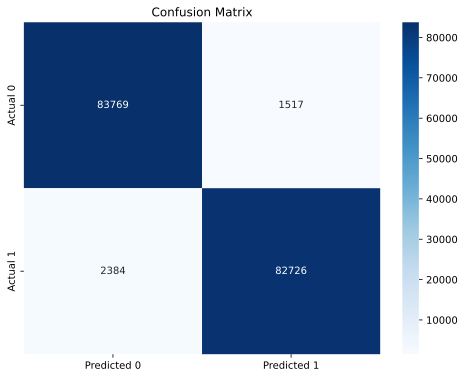

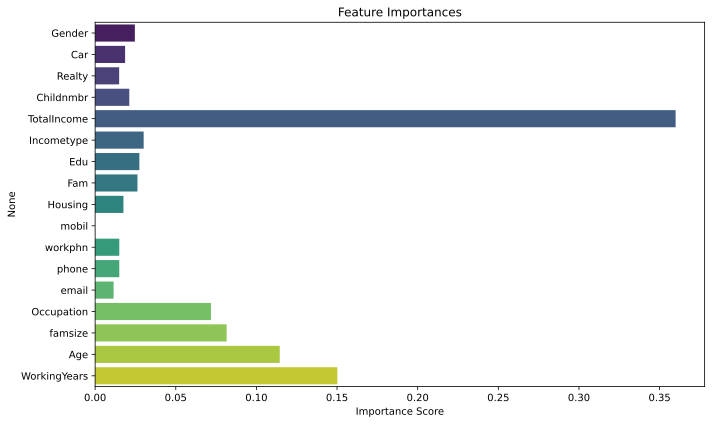

In [ ]:
best_rf_params = study.best_params
best_rf_params.update({'random_state': 42, 'n_jobs': -1})

rf_model = RandomForestClassifier(**best_rf_params)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:, 1]  

print("📊 Classification Report:")
print(classification_report(y_test, y_pred))


plt.figure(figsize=(8, 6)) 
sns.heatmap(confusion_matrix(y_test, y_pred), 
            annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix')
plt.show()


plt.figure(figsize=(10, 6))
sns.barplot(x=rf_model.feature_importances_, y=X_train.columns, palette='viridis')
plt.title('Feature Importances')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()


# ========================================================
# 9. MODEL TRAINING 
# ========================================================

In [ ]:
logistic_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

mlp_model = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    max_iter=1000,
    random_state=42
)

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

svm_model = SVC(
    kernel="rbf",
    probability=True,
    class_weight="balanced",
    random_state=42
)



In [ ]:
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_proba)
    else:
        y_proba = None
        auc = None

    print(f"\n{name} Performance:")
    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred, zero_division=0))
    print("Recall   :", recall_score(y_test, y_pred, zero_division=0))
    print("F1-score :", f1_score(y_test, y_pred, zero_division=0))
    print("ROC-AUC  :", auc)

    return y_proba


# ========================================================
# 10. MODEL TRAINING & EVALUATION
# ========================================================

In [52]:
models = {
    "Logistic": logistic_model,
    "Gradient Boosting": gb_model,
    "MLP": mlp_model,
    "XGBoost": xgb_model,
    "Random Forest": rf_model
}
results = {}
for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    y_proba = evaluate_model(name, model, X_test, y_test)
    results[name] = {
        'model': model,
        'y_proba': y_proba,
        'y_pred': model.predict(X_test)
    }


Training Logistic...

Logistic Performance:
Accuracy : 0.6543463461583605
Precision: 0.664412775673031
Recall   : 0.6222888027258842
F1-score : 0.6426612629228753
ROC-AUC  : 0.7159160831723793

Training Gradient Boosting...

Gradient Boosting Performance:
Accuracy : 0.7964799643184113
Precision: 0.7136924889193976
Recall   : 0.9894841969216308
F1-score : 0.8292591662604808
ROC-AUC  : 0.8633895808956178

Training MLP...

MLP Performance:
Accuracy : 0.619457029507735
Precision: 0.638517161720683
Recall   : 0.5488426741863471
F1-score : 0.5902936177472247
ROC-AUC  : 0.7136197522025547

Training XGBoost...

XGBoost Performance:
Accuracy : 0.818147139604216
Precision: 0.7403437097562059
Recall   : 0.9794266243684644
F1-score : 0.8432664828911762
ROC-AUC  : 0.9115842718296225

Training Random Forest...

Random Forest Performance:
Accuracy : 0.9771062701002371
Precision: 0.9819925691155348
Recall   : 0.9719891904594055
F1-score : 0.9769652737182098
ROC-AUC  : 0.9933745128491794


#  10. COMPARATIVE ANALYSIS

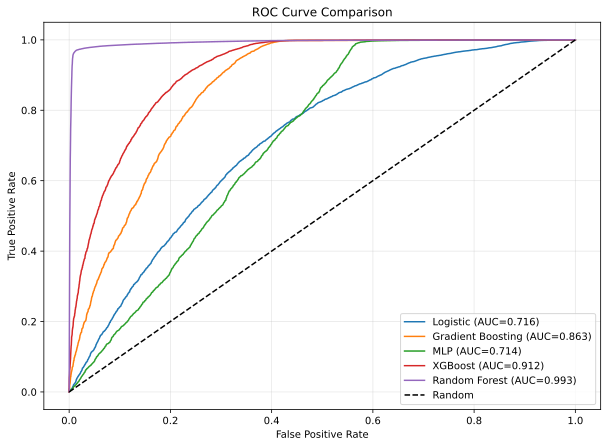

In [ ]:
plt.figure(figsize=(10,7))

for name, r in results.items():
    if r.get("y_proba") is not None:
        y_proba = r["y_proba"]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        auc = roc_auc_score(y_test, y_proba)   # احسبه هنا
        plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0,1],[0,1],"k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
print("\n" + "="*70)
print("MODEL PERFORMANCE SUMMARY")
print("="*70)

comparison_data = []
for name, result in results.items():
    y_pred = result['y_pred']
    comparison_data.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, result['y_proba']) if result['y_proba'] is not None else None
    })

comparison_df = pd.DataFrame(comparison_data)
# Sort by ROC-AUC (descending)
comparison_df = comparison_df.sort_values('ROC-AUC', ascending=False)

print(comparison_df.to_string(index=False))


MODEL PERFORMANCE SUMMARY
            Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
    Random Forest  0.977106   0.981993 0.971989  0.976965 0.993375
          XGBoost  0.818147   0.740344 0.979427  0.843266 0.911584
Gradient Boosting  0.796480   0.713692 0.989484  0.829259 0.863390
         Logistic  0.654346   0.664413 0.622289  0.642661 0.715916
              MLP  0.619457   0.638517 0.548843  0.590294 0.713620


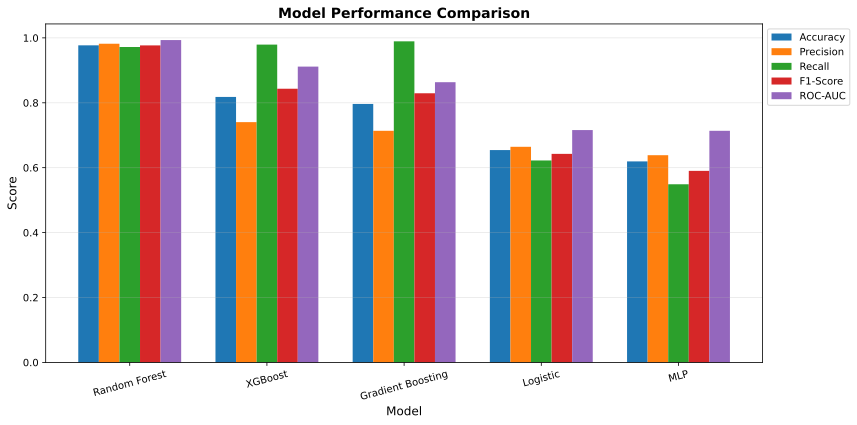

In [59]:
plt.figure(figsize=(12, 6))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(comparison_df['Model']))
width = 0.15

for i, metric in enumerate(metrics):
    values = comparison_df[metric].values
    plt.bar(x + i*width - 2*width, values, width, label=metric)

plt.xlabel('Model', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.xticks(x, comparison_df['Model'], rotation=15)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


In [64]:
print("\n" + "="*70)
print("PROJECT SUMMARY & INSIGHTS")
print("="*70)

print("\n1. DATA OVERVIEW:")
print(f"   - Total samples: {len(X)}")
print(f"   - Default rate: {y.mean():.2%}")
print(f"   - Features used: {X.shape[1]}")
print(f"   - Models tested: {len(comparison_df)}")

print("\n2. KEY FINDINGS:")
best_model = comparison_df.iloc[0]
print("   - Dataset is highly imbalanced (low default rate)")
print(f"   - Best performing model: {best_model['Model']} (AUC: {best_model['ROC-AUC']:.3f})")

if "Gradient Boosting" in list(comparison_df['Model']):
    gb_rank = list(comparison_df['Model']).index("Gradient Boosting") + 1
    print(f"   - Gradient Boosting ranked: {gb_rank} out of {len(comparison_df)}")

print("   - Ensemble methods (RF, XGB, GB) generally outperform linear models")
print("   - All models struggle with precision due to class imbalance")

print("\n3. FEATURE IMPORTANCE:")
rf_importances = rf_model.feature_importances_
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_importances
}).sort_values(by='Importance', ascending=False)
for i, row in importance_df.head(5).iterrows():
    feature_name = row['Feature']
    print(f"   {i+1}. {feature_name}: {row['Importance']:.4f}")

print("\n4. MODEL RECOMMENDATIONS:")
print("   - Random Forest is recommended for deployment")
print("   - Consider ensemble approaches for improved robustness")
print("\n5. BUSINESS IMPLICATIONS:")
print("   - Model can help reduce credit risk (best AUC: {:.3f})".format(best_model['ROC-AUC']))
print("   - High recall is crucial to minimize false negatives (risky approvals)")
print("   - System should be used as decision support with human oversight")
print("   - Regular model retraining is recommended as economic conditions change")



PROJECT SUMMARY & INSIGHTS

1. DATA OVERVIEW:
   - Total samples: 304331
   - Default rate: 93.32%
   - Features used: 17
   - Models tested: 5

2. KEY FINDINGS:
   - Dataset is highly imbalanced (low default rate)
   - Best performing model: Random Forest (AUC: 0.993)
   - Gradient Boosting ranked: 3 out of 5
   - Ensemble methods (RF, XGB, GB) generally outperform linear models
   - All models struggle with precision due to class imbalance

3. FEATURE IMPORTANCE:
   5. TotalIncome: 0.3599
   17. WorkingYears: 0.1502
   16. Age: 0.1145
   15. famsize: 0.0815
   14. Occupation: 0.0718

4. MODEL RECOMMENDATIONS:
   - Random Forest is recommended for deployment
   - Consider ensemble approaches for improved robustness

5. BUSINESS IMPLICATIONS:
   - Model can help reduce credit risk (best AUC: 0.993)
   - High recall is crucial to minimize false negatives (risky approvals)
   - System should be used as decision support with human oversight
   - Regular model retraining is recommended as